In [ ]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_best_v2_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_last_v2_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"
)
EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]

def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)
    if len(edges) < 3:
        return None
    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins

def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()

# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
    - model outputs unconstrained raw scalar u
    - u is mapped to: pred_log = log10(0.5) - softplus(u)
    - pred_raw = 10 ** pred_log
    - Huber loss in log10(BER) space
    - Huber loss in raw BER space
    - optional regime weighting based on raw BER
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta, 0.5 * err * err, delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)
        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr, torch.full_like(weights, self.w_mid), weights
            )
            weights = torch.where(
                target_raw < self.low_thr, torch.full_like(weights, self.w_low), weights
            )
            total = total * weights

        return total.mean()

# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2
        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)
        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            ) if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)], dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
    0 -> scaled tap means multiplied by number of molecules
    1 -> tap variances
    2 -> normalized position
    3 -> abs(scaled tap means)
    4 -> raw-ish log SNR proxy
    5 -> first-position indicator

    Global scalar features:
    0 -> z0 decision margin
    1 -> z1 decision margin
    2 -> min_side_z
    3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )
        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128
        )

        head_in = (
            self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim
        )
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :] # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained

# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)
    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )
    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_msz_raw, temp_msz_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, min_side_z_raw, harmonic_minus_gap_raw,
        X_thr, y_log, **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)
    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_msz_raw, te_msz_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_msz_raw, temp_hmg_raw,
        temp_thr, temp_y_log, **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    min_side_z_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_msz = min_side_z_scaler.fit_transform(t_msz_raw).astype(np.float32)
    v_msz = min_side_z_scaler.transform(v_msz_raw).astype(np.float32)
    te_msz = min_side_z_scaler.transform(te_msz_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]
        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)
        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0
        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)
        return seq

    def build_global_features(z0_scaled, z1_scaled, msz_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, msz_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_msz, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_msz, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_msz, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_mem, num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "min_side_z_scaler": min_side_z_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 4,
        "seq_feature_order": [
            "tap_scaled_mean", "variance", "pos", "abs_tap_scaled_mean",
            "snr_proxy_log", "first_flag",
        ],
        "global_feature_order": [
            "z0_margin", "z1_margin", "min_side_z", "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "min_side_z_definition": "min(z0, z1)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)

# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw

def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)
    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))
            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None
    return metrics

# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH, batch_size=256, nrows=5000000, num_workers=0
    )
    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(), lr=1e-4, weight_decay=1e-5
    )
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False
    for epoch in range(100):
        model.train()
        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad and
                    param.data is not None and
                    not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f" -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model

if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)
    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Generated physical scenario
radius    = 4.101060336906475
distance  = 14.840922996202488
diffusion = 74.78839777698568
Ts        = 0.7146035991704955
N         = 9093
mem_len   = 14
P         = [0.03272521 0.03441102 0.02103229 0.01422137 0.01038743 0.00800178
 0.00640396 0.00527373 0.00444017 0.00380485 0.00330762 0.00290988
 0.00258585 0.00231775]
P_scaled  = [297.57034968 312.89943674 191.24657919 129.31492265  94.45290081
  72.76020203  58.23116764  47.954031    40.37443999  34.59750357
  30.07618607  26.45950894  23.51313718  21.07531734]
variances = [287.832297   302.13224687 187.22422638 127.47588722  93.47177792
  72.17799077  57.85825783  47.70113436  40.19517073  34.46586525
  29.97670548  26.38251503  23.45233572  21.02646998]
Threshold search interval: 0.0 to 1380.5256828195868
sum(P_scaled) = 1380.5256828195868
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.500000       0.500000  2.962506e-08     1.416702e-08
1    2.766585  0.499939 

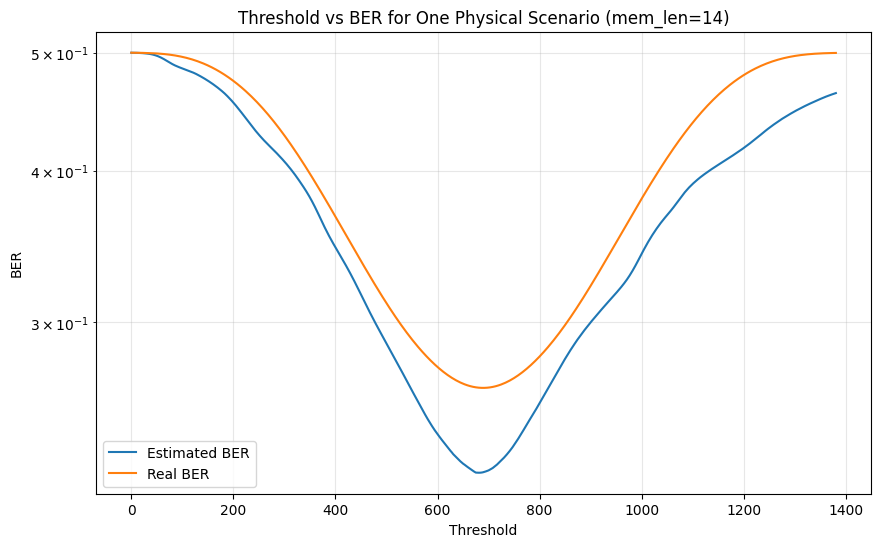

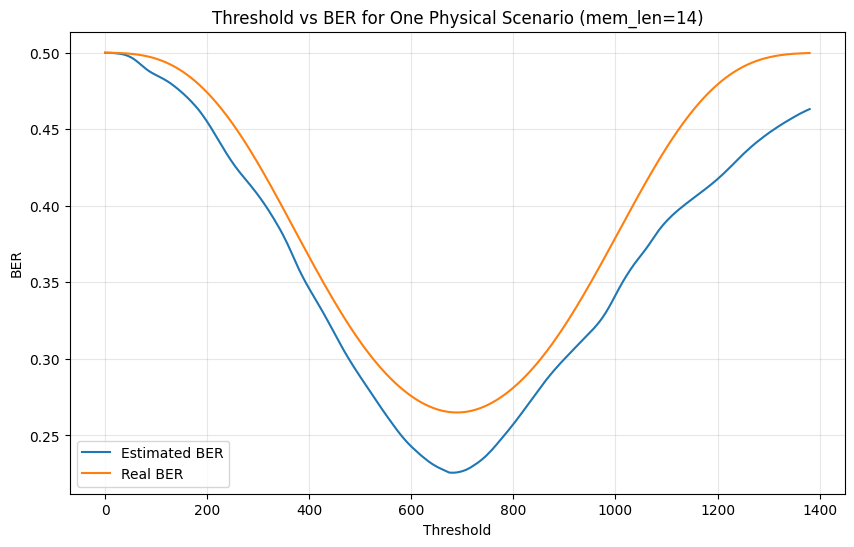

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalboth_best_v2_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.4, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> min_side_z
      3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    min_side_z_scaled = scalers["min_side_z_scaler"].transform(min_side_z_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    # Updated to include all 4 global features
    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, min_side_z_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]

# Updated global_dim fallback to 4 based on training script
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 4), 
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [ ]:
Test Loss: 0.0008 | Test RMSE(log10): 0.0417 | Test MAE(log10): 0.0223 | Typical multiplicative error: ~1.10x | Test RMSE(raw): 0.010037 | Test MAE(raw): 0.006413

Per-range test diagnostics:
low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.0576 | MAE(log10)=0.0237 | factor~1.14x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.1268 | MAE(log10)=0.1131 | factor~1.34x | RMSE(raw)=0.000095 | MAE(raw)=0.000046
high_BER(1e-3<=y<0.10) | count=60956 | RMSE(log10)=0.0461 | MAE(log10)=0.0288 | factor~1.11x | RMSE(raw)=0.002569 | MAE(raw)=0.001799
extreme_BER(y>=0.10) | count=311183 | RMSE(log10)=0.0212 | MAE(log10)=0.0161 | factor~1.05x | RMSE(raw)=0.012468 | MAE(raw)=0.009624
Scalers saved to: ./ber_boundedloghalf_globalboth_scalers_v2_5M.pkl

# Fine tune for high ber

In [2]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

# Input model for fine-tuning
PRETRAINED_MODEL_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_best_v2_5M.pth"
)

# Output paths for the fine-tuned model
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_finetuned_best_v2_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_finetuned_last_v2_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl" # Can reuse existing scalers
)
EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]

def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)
    if len(edges) < 3:
        return None
    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins

def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()

# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta, 0.5 * err * err, delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)
        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr, torch.full_like(weights, self.w_mid), weights
            )
            weights = torch.where(
                target_raw < self.low_thr, torch.full_like(weights, self.w_low), weights
            )
            total = total * weights

        return total.mean()

# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2
        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)
        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            ) if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)], dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )
        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128
        )

        head_in = (
            self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim
        )
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained

# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)
    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )
    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # Global decision features
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_msz_raw, temp_msz_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, min_side_z_raw, harmonic_minus_gap_raw,
        X_thr, y_log, **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)
    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_msz_raw, te_msz_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_msz_raw, temp_hmg_raw,
        temp_thr, temp_y_log, **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    min_side_z_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_msz = min_side_z_scaler.fit_transform(t_msz_raw).astype(np.float32)
    v_msz = min_side_z_scaler.transform(v_msz_raw).astype(np.float32)
    te_msz = min_side_z_scaler.transform(te_msz_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]
        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)
        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0
        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)
        return seq

    def build_global_features(z0_scaled, z1_scaled, msz_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, msz_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_msz, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_msz, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_msz, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_mem, num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "min_side_z_scaler": min_side_z_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 4,
        "seq_feature_order": [
            "tap_scaled_mean", "variance", "pos", "abs_tap_scaled_mean",
            "snr_proxy_log", "first_flag",
        ],
        "global_feature_order": [
            "z0_margin", "z1_margin", "min_side_z", "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "min_side_z_definition": "min(z0, z1)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)

# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw

def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)
    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))
            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None
    return metrics

# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH, batch_size=256, nrows=5000000, num_workers=0
    )
    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    # ---------------------------------------------------------
    # FINE-TUNING INITIALIZATION
    # ---------------------------------------------------------
    if os.path.exists(PRETRAINED_MODEL_PATH):
        print(f"Loading pre-trained model from {PRETRAINED_MODEL_PATH} for fine-tuning...")
        model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
        
        # Lower learning rate for fine-tuning to preserve learned structures
        optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    else:
        print("Pre-trained model not found. Training from scratch...")
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    # ---------------------------------------------------------
    # HIGH-BER TARGETED LOSS FUNCTION
    # ---------------------------------------------------------
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        # Shift focus: less log dominance, more raw dominance
        alpha_log=0.4, 
        beta_raw=0.6,  
        # Turn ON regime weighting specifically to punish high BER errors
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        w_low=0.5,   # Forgive deep tail errors slightly
        w_mid=1.5,
        w_high=5.0,  # Huge penalty for missing high BER predictions
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False
    for epoch in range(100):
        model.train()
        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad and
                    param.data is not None and
                    not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f" -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model

if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)
    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Loading pre-trained model from ./ber_boundedloghalf_globalboth_best_v2_5M.pth for fine-tuning...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-05 | Train Loss: 0.0010 | Val Loss: 0.0010 | Train RMSE(log10): 0.0601 (~1.15x) | Val RMSE(log10): 0.0602 (~1.15x) | Train MAE(log10): 0.0257 | Val MAE(log10): 0.0258 | Train MAE(raw): 0.005730 | Val MAE(raw): 0.005730
 -> New best model saved at epoch 1 with Val Loss: 0.000977
Epoch 002 | LR: 1.00e-05 | Train Loss: 0.0008 | Val Loss: 0.0008 | Train RMSE(log10): 0.0456 (~1.11x) | Val RMSE(log10): 0.0458 (~1.11x) | Train MAE(log10): 0.0235 | Val MAE(log10): 0.0235 | Train MAE(raw): 0.006250 | Val MAE(raw): 0.006249
 -> New best model saved at epoch 2 with Val Loss: 0.000771
Epoch 003 | LR: 1.00e-05 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0475 (~1.12x) | Val RMSE(log10): 0.0478 (~1.12x) | Train MAE(log10): 0.0227 | Val MAE(log10): 0.0227 | 

Epoch 033 | LR: 1.25e-06 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0462 (~1.11x) | Val RMSE(log10): 0.0465 (~1.11x) | Train MAE(log10): 0.0229 | Val MAE(log10): 0.0230 | Train MAE(raw): 0.006181 | Val MAE(raw): 0.006179
Epoch 034 | LR: 1.25e-06 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0406 (~1.10x) | Val RMSE(log10): 0.0408 (~1.10x) | Train MAE(log10): 0.0217 | Val MAE(log10): 0.0217 | Train MAE(raw): 0.006146 | Val MAE(raw): 0.006144
Epoch 035 | LR: 1.25e-06 | Train Loss: 0.0008 | Val Loss: 0.0008 | Train RMSE(log10): 0.0541 (~1.13x) | Val RMSE(log10): 0.0544 (~1.13x) | Train MAE(log10): 0.0246 | Val MAE(log10): 0.0247 | Train MAE(raw): 0.006048 | Val MAE(raw): 0.006046
Epoch 036 | LR: 1.25e-06 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0394 (~1.09x) | Val RMSE(log10): 0.0397 (~1.10x) | Train MAE(log10): 0.0211 | Val MAE(log10): 0.0211 | Train MAE(raw): 0.006181 | Val MAE(raw): 0.006179
 -> New best model saved at epoch 36

Epoch 067 | LR: 3.91e-08 | Train Loss: 0.0008 | Val Loss: 0.0008 | Train RMSE(log10): 0.0491 (~1.12x) | Val RMSE(log10): 0.0494 (~1.12x) | Train MAE(log10): 0.0236 | Val MAE(log10): 0.0237 | Train MAE(raw): 0.006075 | Val MAE(raw): 0.006075
Epoch 068 | LR: 1.95e-08 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0407 (~1.10x) | Val RMSE(log10): 0.0410 (~1.10x) | Train MAE(log10): 0.0210 | Val MAE(log10): 0.0210 | Train MAE(raw): 0.006118 | Val MAE(raw): 0.006116
Epoch 069 | LR: 1.95e-08 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0481 (~1.12x) | Val RMSE(log10): 0.0484 (~1.12x) | Train MAE(log10): 0.0227 | Val MAE(log10): 0.0228 | Train MAE(raw): 0.006026 | Val MAE(raw): 0.006025
Epoch 070 | LR: 1.95e-08 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0423 (~1.10x) | Val RMSE(log10): 0.0426 (~1.10x) | Train MAE(log10): 0.0218 | Val MAE(log10): 0.0219 | Train MAE(raw): 0.006050 | Val MAE(raw): 0.006048
Epoch 071 | LR: 1.95e-08 | Train Los

Generated physical scenario
radius    = 4.101060336906475
distance  = 14.840922996202488
diffusion = 74.78839777698568
Ts        = 0.7146035991704955
N         = 9093
mem_len   = 14
P         = [0.03272521 0.03441102 0.02103229 0.01422137 0.01038743 0.00800178
 0.00640396 0.00527373 0.00444017 0.00380485 0.00330762 0.00290988
 0.00258585 0.00231775]
P_scaled  = [297.57034968 312.89943674 191.24657919 129.31492265  94.45290081
  72.76020203  58.23116764  47.954031    40.37443999  34.59750357
  30.07618607  26.45950894  23.51313718  21.07531734]
variances = [287.832297   302.13224687 187.22422638 127.47588722  93.47177792
  72.17799077  57.85825783  47.70113436  40.19517073  34.46586525
  29.97670548  26.38251503  23.45233572  21.02646998]
Threshold search interval: 0.0 to 1380.5256828195868
sum(P_scaled) = 1380.5256828195868
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.500000       0.500000  2.962506e-08     1.416702e-08
1    2.766585  0.499939 

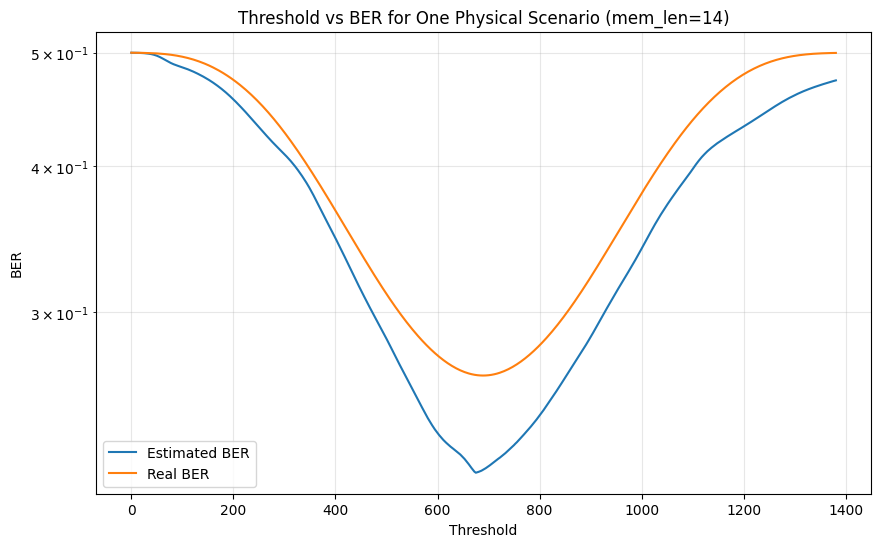

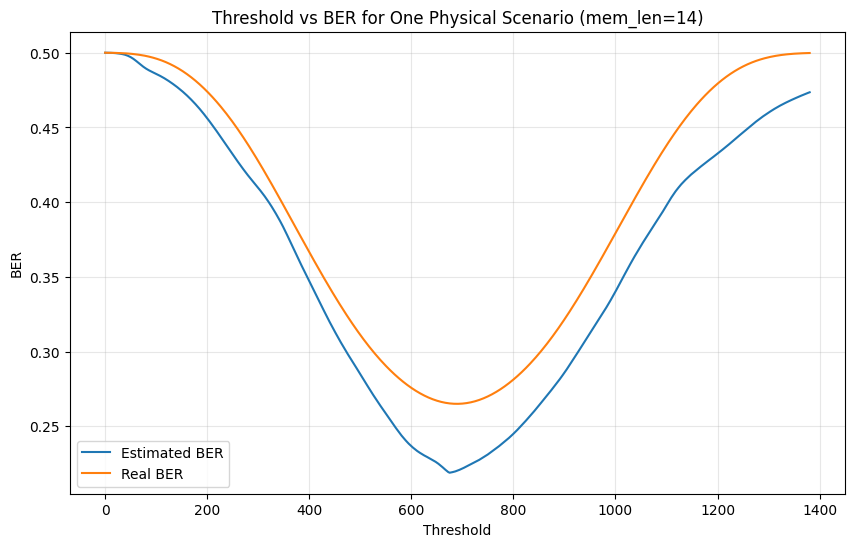

In [3]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalboth_finetuned_best_v2_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.4, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> min_side_z
      3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    min_side_z_scaled = scalers["min_side_z_scaler"].transform(min_side_z_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    # Updated to include all 4 global features
    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, min_side_z_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]

# Updated global_dim fallback to 4 based on training script
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 4), 
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [ ]:
Summary
Mean abs raw error   : 0.02998495008514383
Mean abs log10 error : 0.038470499734036996
Max  abs log10 error : 0.08346797072566492

Best threshold from real BER      : 688.879549142439
Minimum real BER                  : 0.26500239642646706
Best threshold from estimated BER : 675.0466264688961
Estimated BER at that threshold   : 0.21889703

In [ ]:
Summary
Mean abs raw error   : 0.030269459118108535
Mean abs log10 error : 0.03686994669830092
Max  abs log10 error : 0.07014633261836511

Best threshold from real BER      : 688.879549142439
Minimum real BER                  : 0.26500239642646706
Best threshold from estimated BER : 680.5797955383133
Estimated BER at that threshold   : 0.22566137

# Fine tune train_v4 1.08x

In [4]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

# Input model for fine-tuning
PRETRAINED_MODEL_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_best_5M.pth"
)

# Output paths for the fine-tuned model
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_scalers_5M.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    # UPDATED to the 4-bucket strategy to properly track High vs Extreme BER
    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=5000000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    # ---------------------------------------------------------
    # FINE-TUNING INITIALIZATION
    # ---------------------------------------------------------
    if os.path.exists(PRETRAINED_MODEL_PATH):
        print(f"Loading pre-trained model from {PRETRAINED_MODEL_PATH} for fine-tuning...")
        model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
        
        # Lower learning rate to 1e-5 to maintain the learned channel physics
        optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    else:
        print("Pre-trained model not found. Training from scratch...")
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    # ---------------------------------------------------------
    # HIGH-BER TARGETED LOSS FUNCTION
    # ---------------------------------------------------------
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.4, # Shifted balance to heavily favor raw space (high BER)
        beta_raw=0.6,
        use_regime_weights=True, # Enabled regime weighting
        low_thr=1e-4,
        mid_thr=1e-2,
        w_low=0.5,     # Less penalty for deep tail log errors
        w_mid=1.5,
        w_high=5.0,    # Heavy penalty for errors in the high BER regime
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Loading pre-trained model from ./ber_boundedloghalf_globalhmg_best_5M.pth for fine-tuning...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-05 | Train Loss: 0.0008 | Val Loss: 0.0008 | Train RMSE(log10): 0.0481 (~1.12x) | Val RMSE(log10): 0.0480 (~1.12x) | Train MAE(log10): 0.0224 | Val MAE(log10): 0.0223 | Train MAE(raw): 0.004882 | Val MAE(raw): 0.004880
  -> New best model saved at epoch 1 with Val Loss: 0.000761
Epoch 002 | LR: 1.00e-05 | Train Loss: 0.0008 | Val Loss: 0.0008 | Train RMSE(log10): 0.0511 (~1.12x) | Val RMSE(log10): 0.0512 (~1.13x) | Train MAE(log10): 0.0238 | Val MAE(log10): 0.0238 | Train MAE(raw): 0.005092 | Val MAE(raw): 0.005088
Epoch 003 | LR: 1.00e-05 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0479 (~1.12x) | Val RMSE(log10): 0.0480 (~1.12x) | Train MAE(log10): 0.0227 | Val MAE(log10): 0.0227 | Train MAE(raw): 0.004977 | Val MAE(raw): 0.004972
  -> New best

Epoch 033 | LR: 1.25e-06 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0432 (~1.10x) | Val RMSE(log10): 0.0432 (~1.10x) | Train MAE(log10): 0.0212 | Val MAE(log10): 0.0212 | Train MAE(raw): 0.004473 | Val MAE(raw): 0.004468
Epoch 034 | LR: 1.25e-06 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0455 (~1.11x) | Val RMSE(log10): 0.0454 (~1.11x) | Train MAE(log10): 0.0219 | Val MAE(log10): 0.0219 | Train MAE(raw): 0.004561 | Val MAE(raw): 0.004558
Epoch 035 | LR: 1.25e-06 | Train Loss: 0.0009 | Val Loss: 0.0009 | Train RMSE(log10): 0.0541 (~1.13x) | Val RMSE(log10): 0.0541 (~1.13x) | Train MAE(log10): 0.0247 | Val MAE(log10): 0.0247 | Train MAE(raw): 0.004678 | Val MAE(raw): 0.004674
Epoch 036 | LR: 1.25e-06 | Train Loss: 0.0013 | Val Loss: 0.0013 | Train RMSE(log10): 0.0701 (~1.18x) | Val RMSE(log10): 0.0702 (~1.18x) | Train MAE(log10): 0.0297 | Val MAE(log10): 0.0298 | Train MAE(raw): 0.004635 | Val MAE(raw): 0.004633
Epoch 037 | LR: 6.25e-07 | Train Los

Epoch 067 | LR: 1.95e-08 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0473 (~1.11x) | Val RMSE(log10): 0.0473 (~1.12x) | Train MAE(log10): 0.0228 | Val MAE(log10): 0.0228 | Train MAE(raw): 0.004607 | Val MAE(raw): 0.004605
Epoch 068 | LR: 1.95e-08 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0427 (~1.10x) | Val RMSE(log10): 0.0428 (~1.10x) | Train MAE(log10): 0.0212 | Val MAE(log10): 0.0212 | Train MAE(raw): 0.004617 | Val MAE(raw): 0.004613
Epoch 069 | LR: 1.95e-08 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0467 (~1.11x) | Val RMSE(log10): 0.0468 (~1.11x) | Train MAE(log10): 0.0225 | Val MAE(log10): 0.0225 | Train MAE(raw): 0.004610 | Val MAE(raw): 0.004607
Epoch 070 | LR: 1.95e-08 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0428 (~1.10x) | Val RMSE(log10): 0.0428 (~1.10x) | Train MAE(log10): 0.0211 | Val MAE(log10): 0.0211 | Train MAE(raw): 0.004495 | Val MAE(raw): 0.004492
Epoch 071 | LR: 1.95e-08 | Train Los

In [ ]:
Test Loss: 0.0005 | Test RMSE(log10): 0.0337 | Test MAE(log10): 0.0191 | Typical multiplicative error: ~1.08x | Test RMSE(raw): 0.008501 | Test MAE(raw): 0.004985

Per-range test diagnostics:
low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.0379 | MAE(log10)=0.0220 | factor~1.09x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.1157 | MAE(log10)=0.1070 | factor~1.31x | RMSE(raw)=0.000077 | MAE(raw)=0.000044
high_BER(y>=1e-3) | count=372139 | RMSE(log10)=0.0233 | MAE(log10)=0.0147 | factor~1.06x | RMSE(raw)=0.009697 | MAE(raw)=0.006484
Scalers saved to: ./ber_boundedloghalf_globalhmg_scalers_5M.pkl

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.499999       0.500000  8.930280e-07     7.872400e-07
1    0.768953  0.499937       0.496252  3.685283e-03  

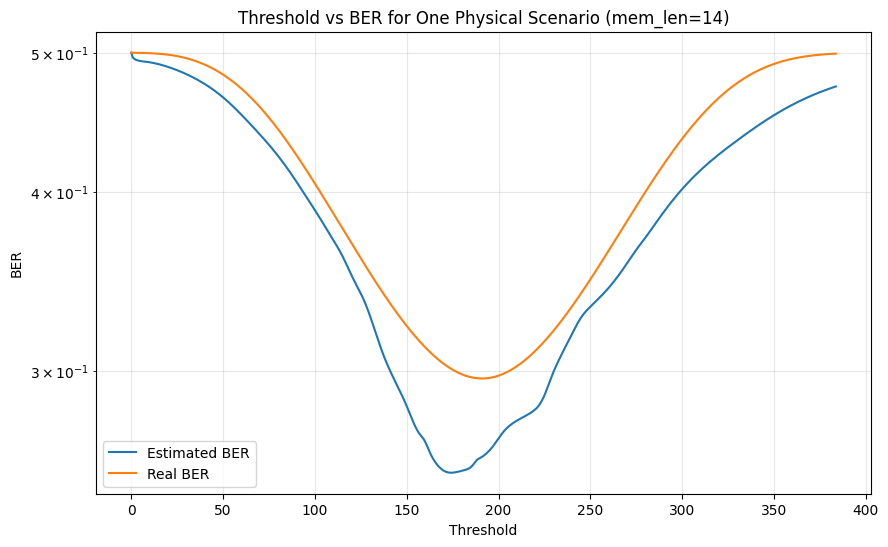

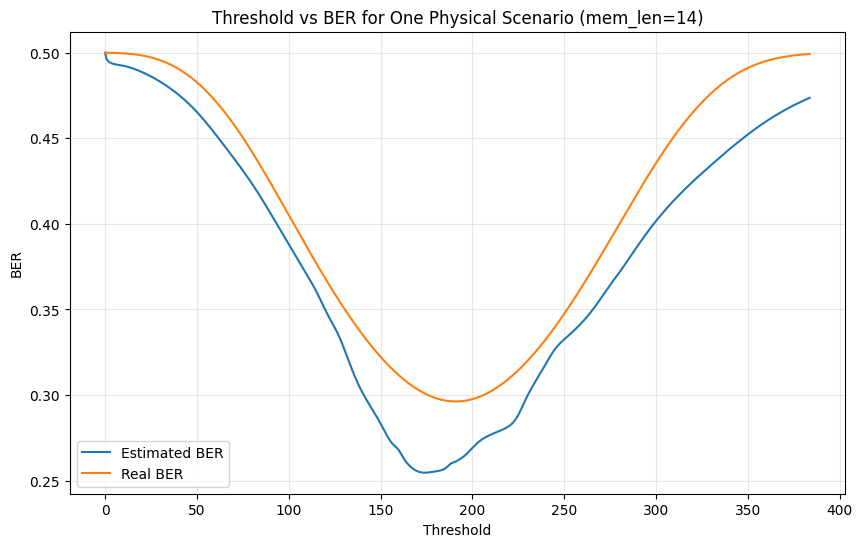

In [5]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalhmg_finetuned_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalhmg_scalers_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [ ]:
Summary
Mean abs raw error   : 0.030515647967043865
Mean abs log10 error : 0.03611633985441906
Max  abs log10 error : 0.08410466203257105

Best threshold from real BER      : 190.70032988848362
Minimum real BER                  : 0.2962519915928659
Best threshold from estimated BER : 185.31765928679255
Estimated BER at that threshold   : 0.24785888

In [ ]:
Summary
Mean abs raw error   : 0.026544473859115257
Mean abs log10 error : 0.03142934369935363
Max  abs log10 error : 0.0746712620942589

Best threshold from real BER      : 190.70032988848362
Minimum real BER                  : 0.2962519915928659
Best threshold from estimated BER : 174.55231808341043
Estimated BER at that threshold   : 0.2546208

In [6]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

# Input model for fine-tuning
PRETRAINED_MODEL_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_best_5M.pth"
)

# Output paths for the fine-tuned model (v2)
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_v2_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_v2_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_scalers_5M.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss (4-Tier)
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - 4-tier regime weighting based on raw BER (low, mid, high, extreme)
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.5,
        alpha_log=0.3,
        beta_raw=0.7,
        use_regime_weights=False,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,
        w_low=0.5,
        w_mid=1.5,
        w_high=3.0,
        w_ext=10.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.ext_thr = ext_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high
        self.w_ext = w_ext

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            # Default to extreme threshold weights
            weights = torch.full_like(target_raw, self.w_ext)
            
            # Cascade down the tiers
            weights = torch.where(
                target_raw < self.ext_thr,
                torch.full_like(weights, self.w_high),
                weights
            )
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1) # This final layer needs zero weight decay
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=5000000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    # ---------------------------------------------------------
    # FINE-TUNING INITIALIZATION
    # ---------------------------------------------------------
    if os.path.exists(PRETRAINED_MODEL_PATH):
        print(f"Loading pre-trained model from {PRETRAINED_MODEL_PATH} for fine-tuning...")
        model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
    else:
        print("Pre-trained model not found. Training from scratch...")

    # ---------------------------------------------------------
    # OPTIMIZER FIX: REMOVE WEIGHT DECAY FROM FINAL LAYER
    # ---------------------------------------------------------
    # Separate the final linear layer to prevent the "rubber band" effect 
    # preventing it from outputting deep negative values for extreme BER.
    head_params = list(model.head[-1].parameters())
    base_params = [p for n, p in model.named_parameters() if not n.startswith('head.8')]

    optimizer = optim.AdamW([
        {'params': base_params, 'weight_decay': 1e-5},
        {'params': head_params, 'weight_decay': 0.0}  # No weight decay here!
    ], lr=1e-5 if os.path.exists(PRETRAINED_MODEL_PATH) else 1e-4)


    # ---------------------------------------------------------
    # HIGH-BER TARGETED LOSS FUNCTION (4 TIER)
    # ---------------------------------------------------------
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.5,     # Increased to 0.5 to force quadratic MSE-like penalty
        alpha_log=0.3,     # Shift focus heavily away from log deep tails
        beta_raw=0.7,      # Care primarily about absolute BER differences
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      # Explicit boundary for extreme BER
        w_low=0.5,         # Forgive deep tail errors
        w_mid=1.5,         
        w_high=3.0,        
        w_ext=10.0,        # Massive penalty for missing the > 0.10 region
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Loading pre-trained model from ./ber_boundedloghalf_globalhmg_finetuned_best_5M.pth for fine-tuning...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-05 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0389 (~1.09x) | Val RMSE(log10): 0.0391 (~1.09x) | Train MAE(log10): 0.0199 | Val MAE(log10): 0.0200 | Train MAE(raw): 0.004819 | Val MAE(raw): 0.004816
  -> New best model saved at epoch 1 with Val Loss: 0.000643
Epoch 002 | LR: 1.00e-05 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0467 (~1.11x) | Val RMSE(log10): 0.0466 (~1.11x) | Train MAE(log10): 0.0223 | Val MAE(log10): 0.0223 | Train MAE(raw): 0.004759 | Val MAE(raw): 0.004756
Epoch 003 | LR: 1.00e-05 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0475 (~1.12x) | Val RMSE(log10): 0.0476 (~1.12x) | Train MAE(log10): 0.0212 | Val MAE(log10): 0.0212 | Train MAE(raw): 0.004162 | Val MAE(raw): 0.004159
Epo

Epoch 033 | LR: 1.25e-06 | Train Loss: 0.0005 | Val Loss: 0.0005 | Train RMSE(log10): 0.0359 (~1.09x) | Val RMSE(log10): 0.0358 (~1.09x) | Train MAE(log10): 0.0180 | Val MAE(log10): 0.0180 | Train MAE(raw): 0.004184 | Val MAE(raw): 0.004184
Epoch 034 | LR: 6.25e-07 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0421 (~1.10x) | Val RMSE(log10): 0.0421 (~1.10x) | Train MAE(log10): 0.0201 | Val MAE(log10): 0.0201 | Train MAE(raw): 0.004154 | Val MAE(raw): 0.004154
Epoch 035 | LR: 6.25e-07 | Train Loss: 0.0008 | Val Loss: 0.0008 | Train RMSE(log10): 0.0544 (~1.13x) | Val RMSE(log10): 0.0544 (~1.13x) | Train MAE(log10): 0.0237 | Val MAE(log10): 0.0237 | Train MAE(raw): 0.004221 | Val MAE(raw): 0.004221
Epoch 036 | LR: 6.25e-07 | Train Loss: 0.0005 | Val Loss: 0.0005 | Train RMSE(log10): 0.0341 (~1.08x) | Val RMSE(log10): 0.0341 (~1.08x) | Train MAE(log10): 0.0172 | Val MAE(log10): 0.0172 | Train MAE(raw): 0.004083 | Val MAE(raw): 0.004084
Epoch 037 | LR: 6.25e-07 | Train Los

Epoch 067 | LR: 1.95e-08 | Train Loss: 0.0005 | Val Loss: 0.0005 | Train RMSE(log10): 0.0293 (~1.07x) | Val RMSE(log10): 0.0293 (~1.07x) | Train MAE(log10): 0.0157 | Val MAE(log10): 0.0157 | Train MAE(raw): 0.004081 | Val MAE(raw): 0.004081
Epoch 068 | LR: 1.95e-08 | Train Loss: 0.0005 | Val Loss: 0.0005 | Train RMSE(log10): 0.0312 (~1.07x) | Val RMSE(log10): 0.0313 (~1.07x) | Train MAE(log10): 0.0165 | Val MAE(log10): 0.0165 | Train MAE(raw): 0.004117 | Val MAE(raw): 0.004117
Epoch 069 | LR: 1.95e-08 | Train Loss: 0.0008 | Val Loss: 0.0008 | Train RMSE(log10): 0.0541 (~1.13x) | Val RMSE(log10): 0.0541 (~1.13x) | Train MAE(log10): 0.0239 | Val MAE(log10): 0.0239 | Train MAE(raw): 0.004223 | Val MAE(raw): 0.004224
Epoch 070 | LR: 1.95e-08 | Train Loss: 0.0005 | Val Loss: 0.0005 | Train RMSE(log10): 0.0350 (~1.08x) | Val RMSE(log10): 0.0350 (~1.08x) | Train MAE(log10): 0.0177 | Val MAE(log10): 0.0177 | Train MAE(raw): 0.004091 | Val MAE(raw): 0.004090
Epoch 071 | LR: 1.95e-08 | Train Los

In [ ]:
Test Loss: 0.0003 | Test RMSE(log10): 0.0283 | Test MAE(log10): 0.0157 | Typical multiplicative error: ~1.07x | Test RMSE(raw): 0.007932 | Test MAE(raw): 0.004444

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.499999       0.500000  8.930280e-07     7.872400e-07
1    0.768953  0.499937       0.495770  4.167187e-03  

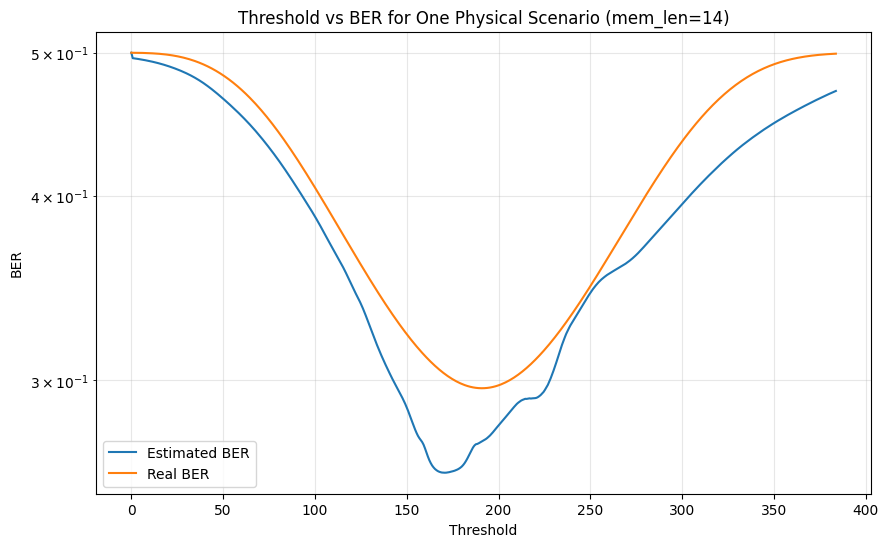

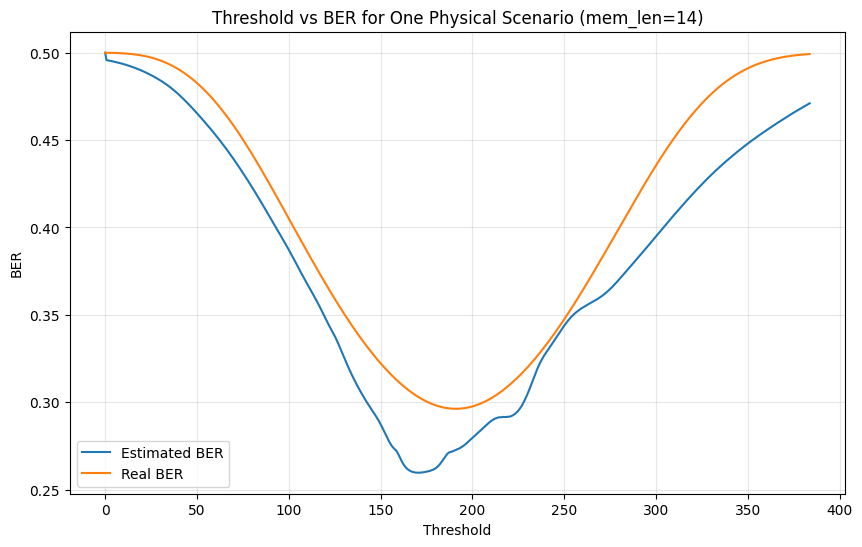

In [7]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalhmg_finetuned_v2_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalhmg_scalers_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [ ]:
Summary
Mean abs raw error   : 0.026544473859115257
Mean abs log10 error : 0.03142934369935363
Max  abs log10 error : 0.0746712620942589

Best threshold from real BER      : 190.70032988848362
Minimum real BER                  : 0.2962519915928659
Best threshold from estimated BER : 174.55231808341043
Estimated BER at that threshold   : 0.2546208

In [ ]:
Summary
Mean abs raw error   : 0.025090585085197105
Mean abs log10 error : 0.02875328397645324
Max  abs log10 error : 0.06989503080558301

Best threshold from real BER      : 190.70032988848362
Minimum real BER                  : 0.2962519915928659
Best threshold from estimated BER : 170.7075533679168
Estimated BER at that threshold   : 0.25966644

In [8]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

# Input model for fine-tuning. We want to load a model BEFORE the wobbles were introduced.
PRETRAINED_MODEL_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_best_5M.pth" 
)

# Output paths for the fine-tuned model (v3)
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_v3_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_v3_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_scalers_5M.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss (4-Tier)
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - 4-tier regime weighting based on raw BER (low, mid, high, extreme)
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.5,
        alpha_log=0.3,
        beta_raw=0.7,
        use_regime_weights=False,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,
        w_low=0.5,
        w_mid=1.5,
        w_high=3.0,
        w_ext=10.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.ext_thr = ext_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high
        self.w_ext = w_ext

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            # Default to extreme threshold weights
            weights = torch.full_like(target_raw, self.w_ext)
            
            # Cascade down the tiers
            weights = torch.where(
                target_raw < self.ext_thr,
                torch.full_like(weights, self.w_high),
                weights
            )
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1) # This final layer needs zero weight decay
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=5000000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    # ---------------------------------------------------------
    # FINE-TUNING INITIALIZATION: FEATURE FREEZING
    # ---------------------------------------------------------
    if os.path.exists(PRETRAINED_MODEL_PATH):
        print(f"Loading pre-trained model from {PRETRAINED_MODEL_PATH} for fine-tuning...")
        model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
        
        print("Freezing CNN backbones to preserve smooth physical topology...")
        # Freeze everything EXCEPT the final head and the global/threshold embeddings
        for name, param in model.named_parameters():
            if not (name.startswith("head") or name.startswith("global_embed") or name.startswith("thr_embed")):
                param.requires_grad = False
    else:
        print("Pre-trained model not found. Training from scratch...")

    # ---------------------------------------------------------
    # OPTIMIZER FIX: REMOVE WEIGHT DECAY FROM FINAL LAYER
    # ---------------------------------------------------------
    # Filter for only the parameters we left unfrozen
    head_final_params = list(model.head[-1].parameters())
    trainable_base_params = [
        p for n, p in model.named_parameters() 
        if p.requires_grad and not n.startswith('head.8')
    ]

    optimizer = optim.AdamW([
        {'params': trainable_base_params, 'weight_decay': 1e-5},
        {'params': head_final_params, 'weight_decay': 0.0}  # No weight decay here!
    ], lr=1e-4 if os.path.exists(PRETRAINED_MODEL_PATH) else 1e-4) # 1e-4 is safe now since CNN is frozen.

    # ---------------------------------------------------------
    # HIGH-BER TARGETED LOSS FUNCTION (4 TIER)
    # ---------------------------------------------------------
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.5,     # Increased to 0.5 to force quadratic MSE-like penalty
        alpha_log=0.3,     # Shift focus heavily away from log deep tails
        beta_raw=0.7,      # Care primarily about absolute BER differences
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      # Explicit boundary for extreme BER
        w_low=0.5,         # Forgive deep tail errors
        w_mid=1.5,         
        w_high=3.0,        
        w_ext=10.0,        # Massive penalty for missing the > 0.10 region
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Loading pre-trained model from ./ber_boundedloghalf_globalhmg_finetuned_best_5M.pth for fine-tuning...
Freezing CNN backbones to preserve smooth physical topology...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0012 | Val Loss: 0.0012 | Train RMSE(log10): 0.0712 (~1.18x) | Val RMSE(log10): 0.0714 (~1.18x) | Train MAE(log10): 0.0312 | Val MAE(log10): 0.0313 | Train MAE(raw): 0.004717 | Val MAE(raw): 0.004719
  -> New best model saved at epoch 1 with Val Loss: 0.001231
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0009 | Val Loss: 0.0009 | Train RMSE(log10): 0.0568 (~1.14x) | Val RMSE(log10): 0.0562 (~1.14x) | Train MAE(log10): 0.0229 | Val MAE(log10): 0.0229 | Train MAE(raw): 0.005874 | Val MAE(raw): 0.005873
  -> New best model saved at epoch 2 with Val Loss: 0.000924
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.0008 | Val Loss: 0.0009 | Train RMSE(log10): 0.0553 (~1.14x) | Val RMSE(log10):

Epoch 033 | LR: 6.25e-06 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0476 (~1.12x) | Val RMSE(log10): 0.0477 (~1.12x) | Train MAE(log10): 0.0207 | Val MAE(log10): 0.0207 | Train MAE(raw): 0.004057 | Val MAE(raw): 0.004058
Epoch 034 | LR: 6.25e-06 | Train Loss: 0.0004 | Val Loss: 0.0004 | Train RMSE(log10): 0.0287 (~1.07x) | Val RMSE(log10): 0.0288 (~1.07x) | Train MAE(log10): 0.0140 | Val MAE(log10): 0.0140 | Train MAE(raw): 0.003634 | Val MAE(raw): 0.003636
  -> New best model saved at epoch 34 with Val Loss: 0.000397
Epoch 035 | LR: 6.25e-06 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0486 (~1.12x) | Val RMSE(log10): 0.0488 (~1.12x) | Train MAE(log10): 0.0209 | Val MAE(log10): 0.0209 | Train MAE(raw): 0.003796 | Val MAE(raw): 0.003797
Epoch 036 | LR: 6.25e-06 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0422 (~1.10x) | Val RMSE(log10): 0.0422 (~1.10x) | Train MAE(log10): 0.0192 | Val MAE(log10): 0.0192 | Train MAE(raw): 0.003942

Epoch 067 | LR: 9.77e-08 | Train Loss: 0.0004 | Val Loss: 0.0004 | Train RMSE(log10): 0.0308 (~1.07x) | Val RMSE(log10): 0.0308 (~1.07x) | Train MAE(log10): 0.0150 | Val MAE(log10): 0.0150 | Train MAE(raw): 0.003774 | Val MAE(raw): 0.003775
Epoch 068 | LR: 9.77e-08 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0500 (~1.12x) | Val RMSE(log10): 0.0501 (~1.12x) | Train MAE(log10): 0.0210 | Val MAE(log10): 0.0211 | Train MAE(raw): 0.003842 | Val MAE(raw): 0.003844
Epoch 069 | LR: 9.77e-08 | Train Loss: 0.0005 | Val Loss: 0.0005 | Train RMSE(log10): 0.0339 (~1.08x) | Val RMSE(log10): 0.0339 (~1.08x) | Train MAE(log10): 0.0159 | Val MAE(log10): 0.0159 | Train MAE(raw): 0.003707 | Val MAE(raw): 0.003710
Epoch 070 | LR: 9.77e-08 | Train Loss: 0.0005 | Val Loss: 0.0005 | Train RMSE(log10): 0.0375 (~1.09x) | Val RMSE(log10): 0.0375 (~1.09x) | Train MAE(log10): 0.0171 | Val MAE(log10): 0.0171 | Train MAE(raw): 0.003782 | Val MAE(raw): 0.003785
Epoch 071 | LR: 4.88e-08 | Train Los

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.499999       0.500000  8.930280e-07     7.872400e-07
1    0.768953  0.499937       0.496959  2.977806e-03  

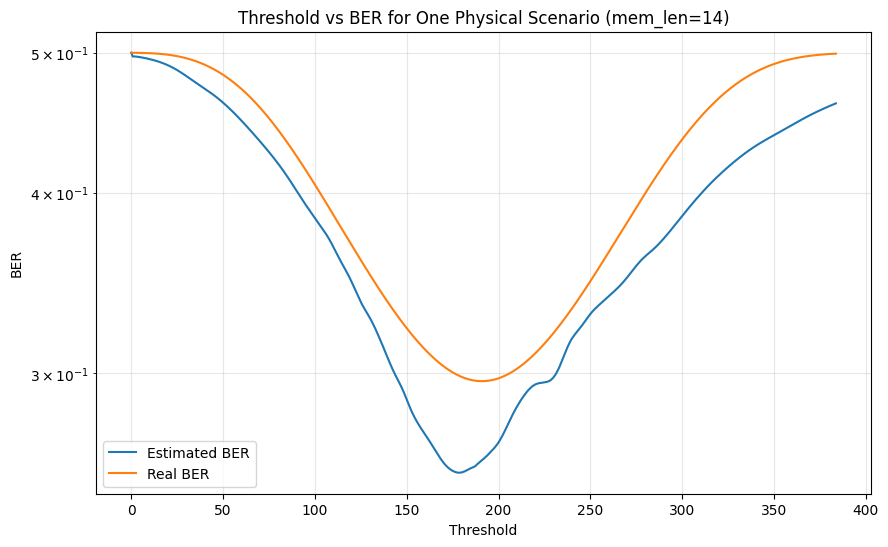

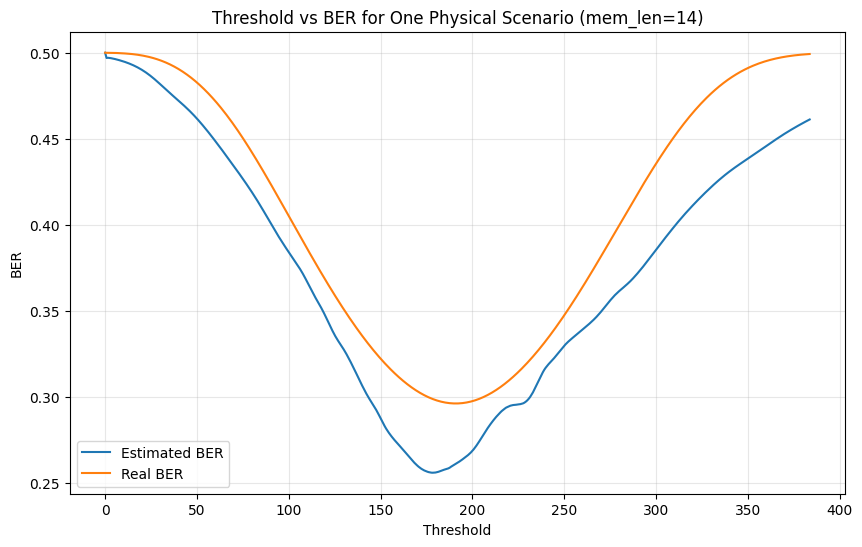

In [9]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalhmg_finetuned_v3_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalhmg_scalers_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Weighted Sampler

In [10]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

# Input model for fine-tuning. We want to load a model BEFORE the wobbles were introduced.
PRETRAINED_MODEL_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_best_5M.pth" 
)

# Output paths for the fine-tuned model (v4)
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_v4_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_v4_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_scalers_5M.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss (4-Tier)
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - 4-tier regime weighting based on raw BER (low, mid, high, extreme)
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.5,
        alpha_log=0.3,
        beta_raw=0.7,
        use_regime_weights=False,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,
        w_low=0.5,
        w_mid=1.5,
        w_high=3.0,
        w_ext=10.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.ext_thr = ext_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high
        self.w_ext = w_ext

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            # Default to extreme threshold weights
            weights = torch.full_like(target_raw, self.w_ext)
            
            # Cascade down the tiers
            weights = torch.where(
                target_raw < self.ext_thr,
                torch.full_like(weights, self.w_high),
                weights
            )
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1) # This final layer needs zero weight decay
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    # ---------------------------------------------------------
    # WEIGHTED RANDOM SAMPLER FOR HIGH-BER FOCUS
    # ---------------------------------------------------------
    # Convert log target back to raw BER space
    t_y_raw_for_weights = np.clip(10 ** t_y_log, EPS, 0.5).reshape(-1)
    
    # Initialize weights to 1.0
    sample_weights = np.ones_like(t_y_raw_for_weights)
    
    # Assign higher sample weights to higher BER regimes (matching loss tiers)
    sample_weights[t_y_raw_for_weights >= 0.10] = 5.0           # Extreme BER
    sample_weights[(t_y_raw_for_weights >= 1e-3) & (t_y_raw_for_weights < 0.10)] = 3.0  # High BER
    sample_weights[(t_y_raw_for_weights >= 1e-4) & (t_y_raw_for_weights < 1e-3)] = 1.0  # Mid BER
    sample_weights[t_y_raw_for_weights < 1e-4] = 0.5            # Low BER

    # Create the PyTorch sampler
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    # Use the sampler in the train_loader (Note: shuffle must be omitted/False)
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=5000000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    # ---------------------------------------------------------
    # FINE-TUNING INITIALIZATION: FEATURE FREEZING
    # ---------------------------------------------------------
    if os.path.exists(PRETRAINED_MODEL_PATH):
        print(f"Loading pre-trained model from {PRETRAINED_MODEL_PATH} for fine-tuning...")
        model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
        
        print("Freezing CNN backbones to preserve smooth physical topology...")
        # Freeze everything EXCEPT the final head and the global/threshold embeddings
        for name, param in model.named_parameters():
            if not (name.startswith("head") or name.startswith("global_embed") or name.startswith("thr_embed")):
                param.requires_grad = False
    else:
        print("Pre-trained model not found. Training from scratch...")

    # ---------------------------------------------------------
    # OPTIMIZER FIX: REMOVE WEIGHT DECAY FROM FINAL LAYER
    # ---------------------------------------------------------
    # Filter for only the parameters we left unfrozen
    head_final_params = list(model.head[-1].parameters())
    trainable_base_params = [
        p for n, p in model.named_parameters() 
        if p.requires_grad and not n.startswith('head.8')
    ]

    optimizer = optim.AdamW([
        {'params': trainable_base_params, 'weight_decay': 1e-5},
        {'params': head_final_params, 'weight_decay': 0.0}  # No weight decay here!
    ], lr=1e-4 if os.path.exists(PRETRAINED_MODEL_PATH) else 1e-4) # 1e-4 is safe now since CNN is frozen.

    # ---------------------------------------------------------
    # HIGH-BER TARGETED LOSS FUNCTION (4 TIER)
    # ---------------------------------------------------------
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.5,     # Increased to 0.5 to force quadratic MSE-like penalty
        alpha_log=0.3,     # Shift focus heavily away from log deep tails
        beta_raw=0.7,      # Care primarily about absolute BER differences
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      # Explicit boundary for extreme BER
        w_low=0.5,         # Forgive deep tail errors
        w_mid=1.5,         
        w_high=3.0,        
        w_ext=10.0,        # Massive penalty for missing the > 0.10 region
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Loading pre-trained model from ./ber_boundedloghalf_globalhmg_finetuned_best_5M.pth for fine-tuning...
Freezing CNN backbones to preserve smooth physical topology...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0011 | Val Loss: 0.0017 | Train RMSE(log10): 0.0601 (~1.15x) | Val RMSE(log10): 0.1255 (~1.33x) | Train MAE(log10): 0.0195 | Val MAE(log10): 0.0390 | Train MAE(raw): 0.006036 | Val MAE(raw): 0.004631
  -> New best model saved at epoch 1 with Val Loss: 0.001661
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0011 | Val Loss: 0.0012 | Train RMSE(log10): 0.0377 (~1.09x) | Val RMSE(log10): 0.0732 (~1.18x) | Train MAE(log10): 0.0185 | Val MAE(log10): 0.0340 | Train MAE(raw): 0.007854 | Val MAE(raw): 0.005932
  -> New best model saved at epoch 2 with Val Loss: 0.001219
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.0008 | Val Loss: 0.0015 | Train RMSE(log10): 0.0614 (~1.15x) | Val RMSE(log10):

Epoch 032 | LR: 2.50e-05 | Train Loss: 0.0006 | Val Loss: 0.0008 | Train RMSE(log10): 0.0330 (~1.08x) | Val RMSE(log10): 0.0634 (~1.16x) | Train MAE(log10): 0.0146 | Val MAE(log10): 0.0334 | Train MAE(raw): 0.005111 | Val MAE(raw): 0.003916
Epoch 033 | LR: 2.50e-05 | Train Loss: 0.0009 | Val Loss: 0.0014 | Train RMSE(log10): 0.0490 (~1.12x) | Val RMSE(log10): 0.0936 (~1.24x) | Train MAE(log10): 0.0186 | Val MAE(log10): 0.0437 | Train MAE(raw): 0.005149 | Val MAE(raw): 0.003999
Epoch 034 | LR: 2.50e-05 | Train Loss: 0.0004 | Val Loss: 0.0005 | Train RMSE(log10): 0.0261 (~1.06x) | Val RMSE(log10): 0.0549 (~1.13x) | Train MAE(log10): 0.0114 | Val MAE(log10): 0.0286 | Train MAE(raw): 0.004237 | Val MAE(raw): 0.003226
Epoch 035 | LR: 1.25e-05 | Train Loss: 0.0004 | Val Loss: 0.0005 | Train RMSE(log10): 0.0252 (~1.06x) | Val RMSE(log10): 0.0551 (~1.14x) | Train MAE(log10): 0.0114 | Val MAE(log10): 0.0294 | Train MAE(raw): 0.004574 | Val MAE(raw): 0.003464
Epoch 036 | LR: 1.25e-05 | Train Los

Epoch 065 | LR: 1.56e-06 | Train Loss: 0.0006 | Val Loss: 0.0008 | Train RMSE(log10): 0.0337 (~1.08x) | Val RMSE(log10): 0.0636 (~1.16x) | Train MAE(log10): 0.0138 | Val MAE(log10): 0.0325 | Train MAE(raw): 0.004432 | Val MAE(raw): 0.003420
Epoch 066 | LR: 1.56e-06 | Train Loss: 0.0005 | Val Loss: 0.0005 | Train RMSE(log10): 0.0261 (~1.06x) | Val RMSE(log10): 0.0494 (~1.12x) | Train MAE(log10): 0.0120 | Val MAE(log10): 0.0276 | Train MAE(raw): 0.004431 | Val MAE(raw): 0.003387
Epoch 067 | LR: 7.81e-07 | Train Loss: 0.0004 | Val Loss: 0.0004 | Train RMSE(log10): 0.0220 (~1.05x) | Val RMSE(log10): 0.0428 (~1.10x) | Train MAE(log10): 0.0107 | Val MAE(log10): 0.0245 | Train MAE(raw): 0.004356 | Val MAE(raw): 0.003319
Epoch 068 | LR: 7.81e-07 | Train Loss: 0.0006 | Val Loss: 0.0008 | Train RMSE(log10): 0.0338 (~1.08x) | Val RMSE(log10): 0.0634 (~1.16x) | Train MAE(log10): 0.0138 | Val MAE(log10): 0.0324 | Train MAE(raw): 0.004394 | Val MAE(raw): 0.003391
Epoch 069 | LR: 7.81e-07 | Train Los

In [ ]:
Test Loss: 0.0004 | Test RMSE(log10): 0.0245 | Test MAE(log10): 0.0122 | Typical multiplicative error: ~1.06x | Test RMSE(raw): 0.007623 | Test MAE(raw): 0.003712

Per-range test diagnostics:
low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.0393 | MAE(log10)=0.0184 | factor~1.09x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.0601 | MAE(log10)=0.0506 | factor~1.15x | RMSE(raw)=0.000034 | MAE(raw)=0.000017
high_BER(1e-3<=y<0.10) | count=60956 | RMSE(log10)=0.0282 | MAE(log10)=0.0181 | factor~1.07x | RMSE(raw)=0.001493 | MAE(raw)=0.001006
extreme_BER(y>=0.10) | count=311183 | RMSE(log10)=0.0108 | MAE(log10)=0.0072 | factor~1.03x | RMSE(raw)=0.009486 | MAE(raw)=0.005578
Scalers saved to: ./ber_boundedloghalf_globalhmg_scalers_5M.pkl

Generated physical scenario
radius    = 4.101060336906475
distance  = 14.840922996202488
diffusion = 74.78839777698568
Ts        = 2.3932544989631195
N         = 9093
mem_len   = 5
P         = [0.09370588 0.03168028 0.01548203 0.00958482 0.00667532]
P_scaled  = [852.06757844 288.06879139 140.77812921  87.15476132  60.69872677]
variances = [772.2238351  278.94269125 138.59859752  86.31939868  60.29354307]
Threshold search interval: 0.0 to 1428.7679871266364
sum(P_scaled) = 1428.7679871266364
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.500000       0.500000  2.980232e-08     1.432099e-08
1    2.863262  0.468750       0.441840  2.690992e-02     2.567618e-02
2    5.726525  0.468750       0.443149  2.560142e-02     2.439191e-02
3    8.589787  0.468750       0.444916  2.383438e-02     2.266364e-02
4   11.453050  0.468750       0.446537  2.221316e-02     2.108400e-02
5   14.316312  0.468750       0.447921  2.082869e-02     1.973956e-02
6   17.179575 

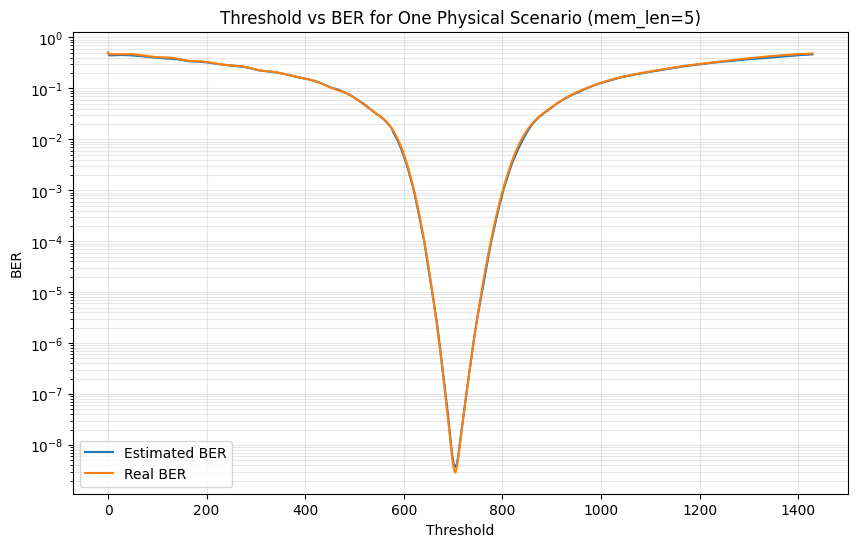

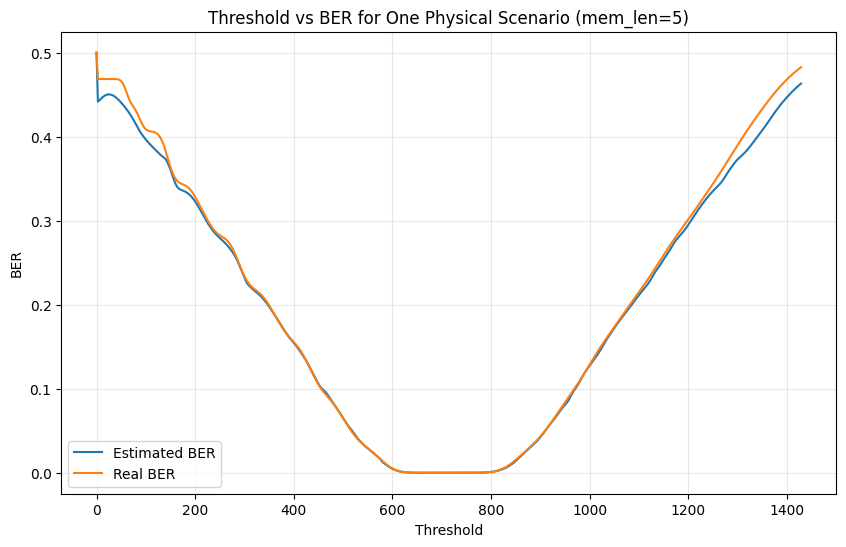

In [13]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalhmg_finetuned_v4_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalhmg_scalers_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# V3 with memory weighted sampler

In [14]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

# Input model for fine-tuning. We want to load a model BEFORE the wobbles were introduced.
PRETRAINED_MODEL_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_v3_best_5M.pth" 
)

# Output paths for the fine-tuned model (v3 with mem_len sampler)
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_v5_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_finetuned_v5_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_scalers_5M.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss (4-Tier)
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - 4-tier regime weighting based on raw BER (low, mid, high, extreme)
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.5,
        alpha_log=0.3,
        beta_raw=0.7,
        use_regime_weights=False,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,
        w_low=0.5,
        w_mid=1.5,
        w_high=3.0,
        w_ext=10.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.ext_thr = ext_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high
        self.w_ext = w_ext

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            # Default to extreme threshold weights
            weights = torch.full_like(target_raw, self.w_ext)
            
            # Cascade down the tiers
            weights = torch.where(
                target_raw < self.ext_thr,
                torch.full_like(weights, self.w_high),
                weights
            )
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1) # This final layer needs zero weight decay
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    # Added mem_len extraction for the sampler
    mem_len_raw = df["mem_len"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log,
        t_mem_len, temp_mem_len # Added to train/test split
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log, mem_len_raw,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log,
        v_mem_len, te_mem_len # Added to val/test split
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log, temp_mem_len,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()
    
    # ---------------------------------------------------------
    # WEIGHTED RANDOM SAMPLER BASED ON MEM_LEN
    # ---------------------------------------------------------
    t_mem_len_flat = t_mem_len.reshape(-1)
    mask_lt_8 = t_mem_len_flat < 8
    mask_ge_8 = t_mem_len_flat >= 8

    count_lt_8 = mask_lt_8.sum()
    count_ge_8 = mask_ge_8.sum()

    sample_weights = np.zeros_like(t_mem_len_flat, dtype=np.float64)

    # Assign inverse frequency weights to guarantee a 50/50 probability split
    if count_lt_8 > 0:
        sample_weights[mask_lt_8] = 1.0 / count_lt_8
    if count_ge_8 > 0:
        sample_weights[mask_ge_8] = 1.0 / count_ge_8

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler, # Replaced shuffle=True with sampler
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=5000000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    # ---------------------------------------------------------
    # FINE-TUNING INITIALIZATION: FEATURE FREEZING
    # ---------------------------------------------------------
    if os.path.exists(PRETRAINED_MODEL_PATH):
        print(f"Loading pre-trained model from {PRETRAINED_MODEL_PATH} for fine-tuning...")
        model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
        
        print("Freezing CNN backbones to preserve smooth physical topology...")
        # Freeze everything EXCEPT the final head and the global/threshold embeddings
        for name, param in model.named_parameters():
            if not (name.startswith("head") or name.startswith("global_embed") or name.startswith("thr_embed")):
                param.requires_grad = False
    else:
        print("Pre-trained model not found. Training from scratch...")

    # ---------------------------------------------------------
    # OPTIMIZER FIX: REMOVE WEIGHT DECAY FROM FINAL LAYER
    # ---------------------------------------------------------
    # Filter for only the parameters we left unfrozen
    head_final_params = list(model.head[-1].parameters())
    trainable_base_params = [
        p for n, p in model.named_parameters() 
        if p.requires_grad and not n.startswith('head.8')
    ]

    optimizer = optim.AdamW([
        {'params': trainable_base_params, 'weight_decay': 1e-5},
        {'params': head_final_params, 'weight_decay': 0.0}  # No weight decay here!
    ], lr=1e-4 if os.path.exists(PRETRAINED_MODEL_PATH) else 1e-4) # 1e-4 is safe now since CNN is frozen.

    # ---------------------------------------------------------
    # HIGH-BER TARGETED LOSS FUNCTION (4 TIER)
    # ---------------------------------------------------------
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.5,     # Increased to 0.5 to force quadratic MSE-like penalty
        alpha_log=0.3,     # Shift focus heavily away from log deep tails
        beta_raw=0.7,      # Care primarily about absolute BER differences
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      # Explicit boundary for extreme BER
        w_low=0.5,         # Forgive deep tail errors
        w_mid=1.5,         
        w_high=3.0,        
        w_ext=10.0,        # Massive penalty for missing the > 0.10 region
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Loading pre-trained model from ./ber_boundedloghalf_globalhmg_finetuned_v3_best_5M.pth for fine-tuning...
Freezing CNN backbones to preserve smooth physical topology...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0014 | Val Loss: 0.0011 | Train RMSE(log10): 0.0542 (~1.13x) | Val RMSE(log10): 0.0696 (~1.17x) | Train MAE(log10): 0.0226 | Val MAE(log10): 0.0264 | Train MAE(raw): 0.009086 | Val MAE(raw): 0.005232
  -> New best model saved at epoch 1 with Val Loss: 0.001073
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0012 | Val Loss: 0.0008 | Train RMSE(log10): 0.0442 (~1.11x) | Val RMSE(log10): 0.0560 (~1.14x) | Train MAE(log10): 0.0190 | Val MAE(log10): 0.0201 | Train MAE(raw): 0.009125 | Val MAE(raw): 0.005268
  -> New best model saved at epoch 2 with Val Loss: 0.000844
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.0012 | Val Loss: 0.0012 | Train RMSE(log10): 0.0677 (~1.17x) | Val RMSE(log1

Epoch 033 | LR: 1.25e-05 | Train Loss: 0.0009 | Val Loss: 0.0005 | Train RMSE(log10): 0.0283 (~1.07x) | Val RMSE(log10): 0.0344 (~1.08x) | Train MAE(log10): 0.0146 | Val MAE(log10): 0.0151 | Train MAE(raw): 0.007514 | Val MAE(raw): 0.004061
Epoch 034 | LR: 6.25e-06 | Train Loss: 0.0009 | Val Loss: 0.0005 | Train RMSE(log10): 0.0282 (~1.07x) | Val RMSE(log10): 0.0342 (~1.08x) | Train MAE(log10): 0.0149 | Val MAE(log10): 0.0157 | Train MAE(raw): 0.007422 | Val MAE(raw): 0.003997
Epoch 035 | LR: 6.25e-06 | Train Loss: 0.0009 | Val Loss: 0.0007 | Train RMSE(log10): 0.0365 (~1.09x) | Val RMSE(log10): 0.0461 (~1.11x) | Train MAE(log10): 0.0172 | Val MAE(log10): 0.0197 | Train MAE(raw): 0.007460 | Val MAE(raw): 0.004091
Epoch 036 | LR: 6.25e-06 | Train Loss: 0.0009 | Val Loss: 0.0005 | Train RMSE(log10): 0.0271 (~1.06x) | Val RMSE(log10): 0.0327 (~1.08x) | Train MAE(log10): 0.0142 | Val MAE(log10): 0.0144 | Train MAE(raw): 0.007534 | Val MAE(raw): 0.004048
Epoch 037 | LR: 6.25e-06 | Train Los

Epoch 067 | LR: 9.77e-08 | Train Loss: 0.0009 | Val Loss: 0.0006 | Train RMSE(log10): 0.0305 (~1.07x) | Val RMSE(log10): 0.0375 (~1.09x) | Train MAE(log10): 0.0156 | Val MAE(log10): 0.0168 | Train MAE(raw): 0.007481 | Val MAE(raw): 0.004073
Epoch 068 | LR: 9.77e-08 | Train Loss: 0.0008 | Val Loss: 0.0005 | Train RMSE(log10): 0.0274 (~1.07x) | Val RMSE(log10): 0.0332 (~1.08x) | Train MAE(log10): 0.0145 | Val MAE(log10): 0.0151 | Train MAE(raw): 0.007390 | Val MAE(raw): 0.003997
Epoch 069 | LR: 4.88e-08 | Train Loss: 0.0008 | Val Loss: 0.0005 | Train RMSE(log10): 0.0267 (~1.06x) | Val RMSE(log10): 0.0323 (~1.08x) | Train MAE(log10): 0.0145 | Val MAE(log10): 0.0149 | Train MAE(raw): 0.007414 | Val MAE(raw): 0.004039
Epoch 070 | LR: 4.88e-08 | Train Loss: 0.0008 | Val Loss: 0.0005 | Train RMSE(log10): 0.0249 (~1.06x) | Val RMSE(log10): 0.0298 (~1.07x) | Train MAE(log10): 0.0138 | Val MAE(log10): 0.0138 | Train MAE(raw): 0.007448 | Val MAE(raw): 0.004009
Epoch 071 | LR: 4.88e-08 | Train Los

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER  abs_error  abs_log10_error
0    0.000000  0.499999       0.499997   0.000002         0.000001
1    0.768953  0.499937       0.499482   0.000455         0.

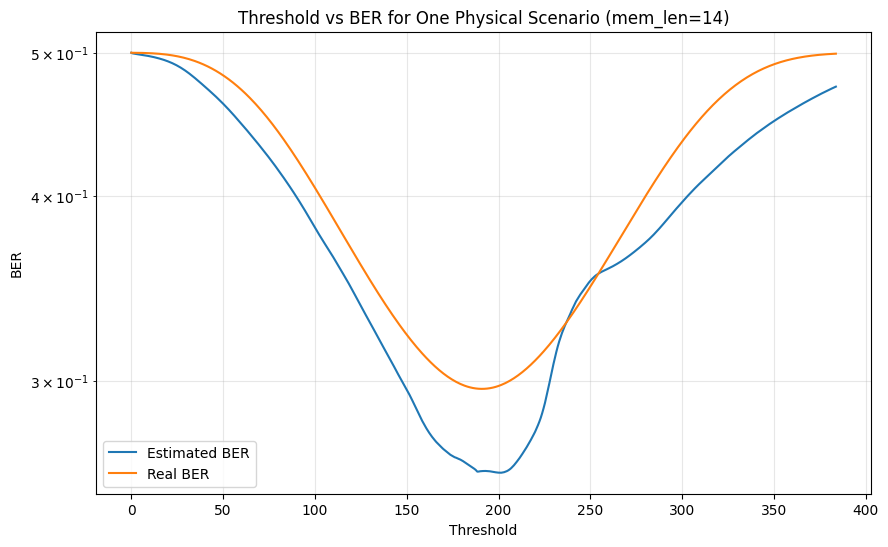

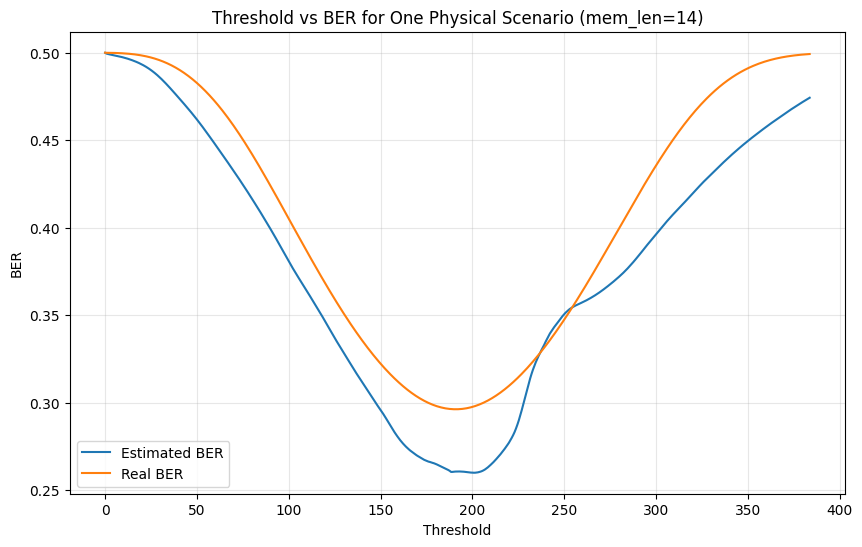

In [15]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalhmg_finetuned_v5_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalhmg_scalers_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Data is in a different shape now

In [1]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import h5py
from sklearn.preprocessing import StandardScaler

# =========================
# Configuration
# =========================
BASE_DIR = "./"
# Add all your massive CSVs to this list
CSV_PATHS = [
    os.path.join(BASE_DIR, "data_physics_with_variances_total.csv"),
    os.path.join(BASE_DIR, "data_physics_with_variances_total_v2.csv")
]

H5_TRAIN_PATH = os.path.join(BASE_DIR, "train_physics.h5")
H5_VAL_PATH = os.path.join(BASE_DIR, "val_physics.h5")
H5_TEST_PATH = os.path.join(BASE_DIR, "test_physics.h5")
SCALER_SAVE_PATH = os.path.join(BASE_DIR, "ber_boundedloghalf_globalhmg_scalers_massive.pkl")

CHUNKSIZE = 500_000  # Process 500k rows at a time
EPS = 1e-12
RANDOM_SEED = 42

def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]

def process_raw_chunk(df):
    """Applies the raw math transformations before scaling."""
    df = df[df["mem_len"] != 1].copy()
    
    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")
    
    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    X_vars_feat = X_vars_raw.astype(np.float32)
    
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)
    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)
    
    harmonic_side_z_raw = (2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    hmg_raw = (harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw).astype(np.float32)

    return X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw, z0_raw, z1_raw, hmg_raw, X_thr, y_log, len(tap_cols)

def append_to_h5(h5_path, dataset_names, data_tuples):
    """Appends chunks of data to HDF5 files on disk."""
    with h5py.File(h5_path, 'a') as f:
        for name, data in zip(dataset_names, data_tuples):
            if name not in f:
                # Create resizable dataset
                maxshape = (None,) + data.shape[1:]
                f.create_dataset(name, data=data, maxshape=maxshape, chunks=True, compression="lzf")
            else:
                # Resize and append
                f[name].resize((f[name].shape[0] + data.shape[0]), axis=0)
                f[name][-data.shape[0]:] = data

def build_datasets():
    # Initialize Scalers
    scalers = {
        "tap_scaler": StandardScaler(), "var_scaler": StandardScaler(),
        "abs_scaler": StandardScaler(), "snr_scaler": StandardScaler(),
        "z0_scaler": StandardScaler(), "z1_scaler": StandardScaler(),
        "harmonic_minus_gap_scaler": StandardScaler(), "thr_scaler": StandardScaler()
    }
    
    print("--- PASS 1: Fitting Scalers on Training Data ---")
    rng = np.random.RandomState(RANDOM_SEED)
    
    for csv_path in CSV_PATHS:
        print(f"Reading {csv_path}...")
        for chunk in pd.read_csv(csv_path, chunksize=CHUNKSIZE):
            taps, vars_, abs_taps, snr, z0, z1, hmg, thr, y_log, L = process_raw_chunk(chunk)
            
            # Determine Train/Val/Test splits consistently via seeded random logic
            # ~70% Train, 15% Val, 15% Test
            rand_vals = rng.rand(len(taps))
            train_mask = rand_vals < 0.70
            
            if not np.any(train_mask):
                continue
                
            # Fit only on training split to prevent data leakage
            scalers["tap_scaler"].partial_fit(taps[train_mask])
            scalers["var_scaler"].partial_fit(vars_[train_mask])
            scalers["abs_scaler"].partial_fit(abs_taps[train_mask])
            scalers["snr_scaler"].partial_fit(snr[train_mask])
            scalers["z0_scaler"].partial_fit(z0[train_mask])
            scalers["z1_scaler"].partial_fit(z1[train_mask])
            scalers["harmonic_minus_gap_scaler"].partial_fit(hmg[train_mask])
            scalers["thr_scaler"].partial_fit(thr[train_mask])
            
    # Save scalers
    scalers["seq_len"] = L
    scalers["global_dim"] = 3
    joblib.dump(scalers, SCALER_SAVE_PATH)
    print(f"Scalers saved to {SCALER_SAVE_PATH}")

    # Remove old HDF5 files if they exist
    for p in [H5_TRAIN_PATH, H5_VAL_PATH, H5_TEST_PATH]:
        if os.path.exists(p): os.remove(p)

    print("\n--- PASS 2: Transforming and Writing to HDF5 ---")
    rng = np.random.RandomState(RANDOM_SEED) # Reset seed to ensure exact same split masks
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    
    for csv_path in CSV_PATHS:
        print(f"Processing {csv_path}...")
        for chunk in pd.read_csv(csv_path, chunksize=CHUNKSIZE):
            taps, vars_, abs_taps, snr, z0, z1, hmg, thr, y_log, _ = process_raw_chunk(chunk)
            
            # Recreate exact same masks
            rand_vals = rng.rand(len(taps))
            train_mask = rand_vals < 0.70
            val_mask = (rand_vals >= 0.70) & (rand_vals < 0.85)
            test_mask = rand_vals >= 0.85
            
            # Transform all
            taps_s = scalers["tap_scaler"].transform(taps).astype(np.float32)
            vars_s = scalers["var_scaler"].transform(vars_).astype(np.float32)
            abs_s = scalers["abs_scaler"].transform(abs_taps).astype(np.float32)
            snr_s = scalers["snr_scaler"].transform(snr).astype(np.float32)
            z0_s = scalers["z0_scaler"].transform(z0).astype(np.float32)
            z1_s = scalers["z1_scaler"].transform(z1).astype(np.float32)
            hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
            thr_s = scalers["thr_scaler"].transform(thr).astype(np.float32)

            pos_ch = np.tile(pos, (len(taps), 1)).astype(np.float32)
            first_flag = np.zeros((len(taps), L), dtype=np.float32)
            first_flag[:, 0] = 1.0

            seq = np.stack([taps_s, vars_s, pos_ch, abs_s, snr_s, first_flag], axis=1)
            global_feats = np.concatenate([z0_s, z1_s, hmg_s], axis=1)
            
            names = ["seq", "global_feats", "thr", "y_log"]
            
            if np.any(train_mask):
                append_to_h5(H5_TRAIN_PATH, names, (seq[train_mask], global_feats[train_mask], thr_s[train_mask], y_log[train_mask]))
            if np.any(val_mask):
                append_to_h5(H5_VAL_PATH, names, (seq[val_mask], global_feats[val_mask], thr_s[val_mask], y_log[val_mask]))
            if np.any(test_mask):
                append_to_h5(H5_TEST_PATH, names, (seq[test_mask], global_feats[test_mask], thr_s[test_mask], y_log[test_mask]))

    print("DONE! Massive dataset successfully compiled to disk.")

if __name__ == "__main__":
    build_datasets()

--- PASS 1: Fitting Scalers on Training Data ---
Reading ./data_physics_with_variances_total.csv...
Reading ./data_physics_with_variances_total_v2.csv...
Scalers saved to ./ber_boundedloghalf_globalhmg_scalers_massive.pkl

--- PASS 2: Transforming and Writing to HDF5 ---
Processing ./data_physics_with_variances_total.csv...
Processing ./data_physics_with_variances_total_v2.csv...
DONE! Massive dataset successfully compiled to disk.
